In [2]:
import numpy as np
import cv2
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
img_path = 'images.jpeg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

In [4]:
img = img.astype(np.float32)
np.savetxt('image.txt', img, fmt='%d')

In [10]:
def haar_transform(image):
    rows, columns = image.shape
    row_transform = np.zeros_like(image, dtype=np.float32)
    for i in range(rows):
        for j in range(0, columns - 1, 2):
            row_transform[i, j // 2] = (image[i, j] + image[i, j + 1]) / 2
            row_transform[i, (j // 2) + columns // 2] = (image[i, j] - image[i, j + 1]) / 2
    result = np.zeros_like(row_transform, dtype=np.float32)
    for j in range(columns):
        for i in range(0, rows - 1, 2):
            result[i // 2, j] = (row_transform[i, j] + row_transform[i + 1, j]) / 2
            result[(i // 2) + rows // 2, j] = (row_transform[i, j] - row_transform[i + 1, j]) / 2
    LL = result[:rows // 2, :columns // 2]  
    LH = result[:rows // 2, columns // 2:]  
    HL = result[rows // 2:, :columns // 2] 
    HH = result[rows // 2:, columns // 2:]

    return LL, LH, HL, HH, result

LL, LH, HL, HH, result = haar_transform(img)
n_quants = 4

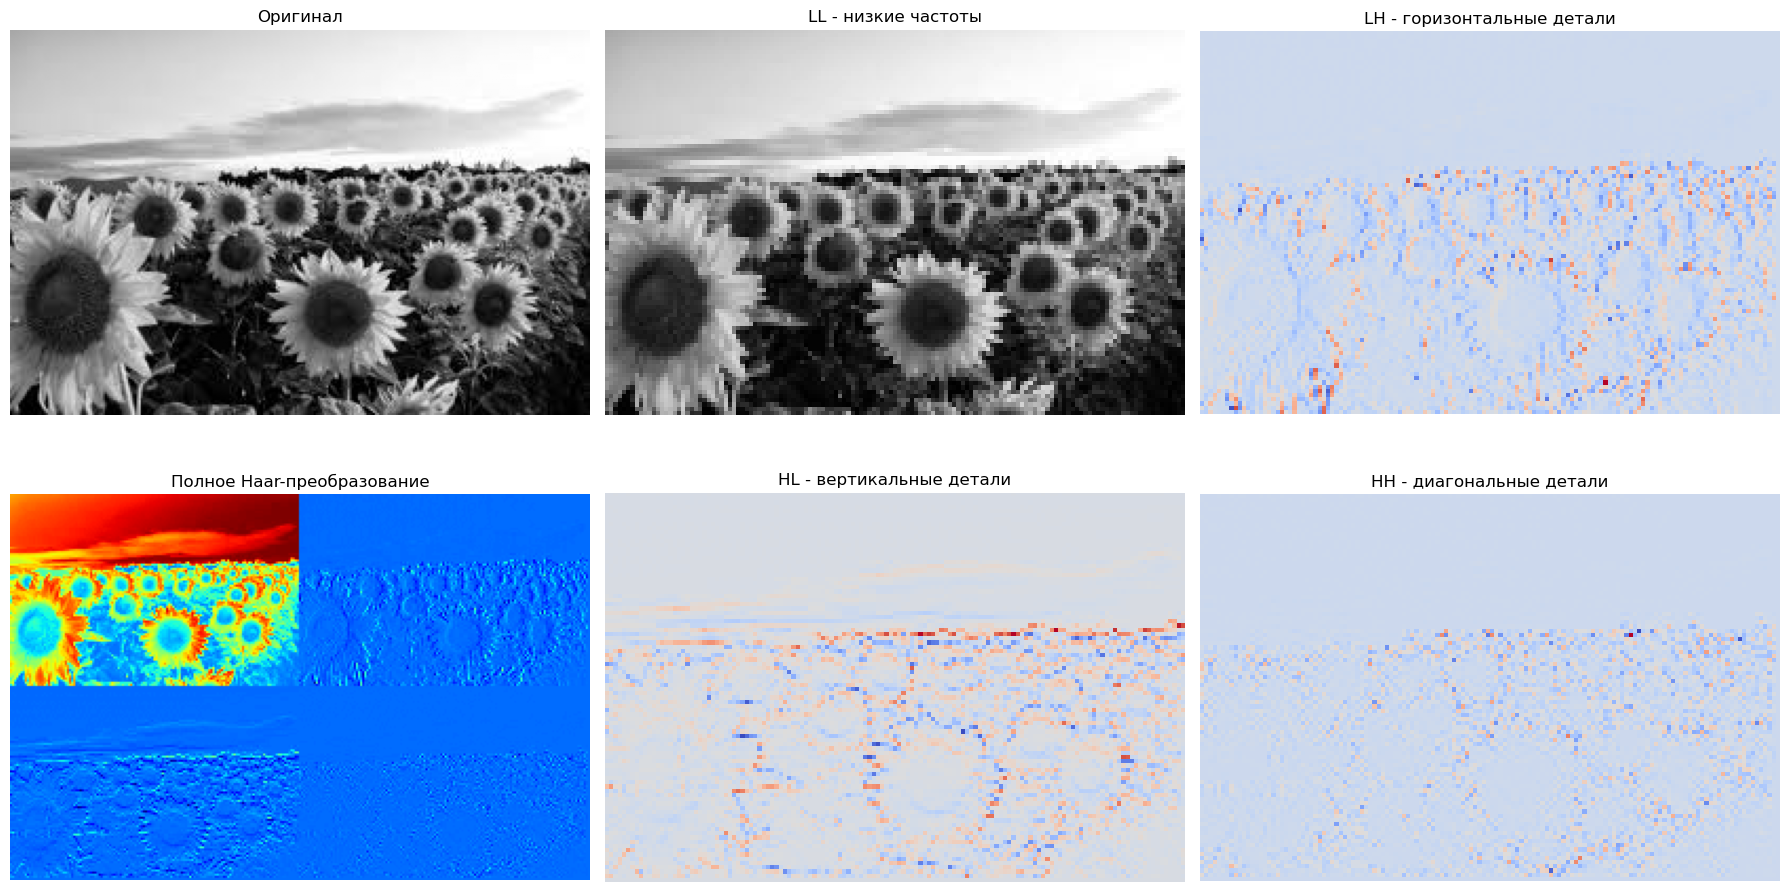

In [11]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title('Оригинал'); plt.axis('off')
plt.subplot(2, 3, 4); plt.imshow(result, cmap='jet'); plt.title('Полное Haar-преобразование'); plt.axis('off')

plt.subplot(2, 3, 2); plt.imshow(LL, cmap='gray'); plt.title('LL - низкие частоты'); plt.axis('off')
plt.subplot(2, 3, 3); plt.imshow(LH, cmap='coolwarm'); plt.title('LH - горизонтальные детали'); plt.axis('off')
plt.subplot(2, 3, 5); plt.imshow(HL, cmap='coolwarm'); plt.title('HL - вертикальные детали'); plt.axis('off')
plt.subplot(2, 3, 6); plt.imshow(HH, cmap='coolwarm'); plt.title('HH - диагональные детали'); plt.axis('off')

plt.tight_layout()
plt.show()   


In [13]:
def quantize(coeffs, n_quants):
    min_val = np.min(coeffs)
    max_val = np.max(coeffs)
    step = (max_val - min_val) / n_quants
    quantized = np.round((coeffs - min_val) / step).astype(int)
    return quantized, min_val, step

LH_q, LH_min, LH_step = quantize(LH, n_quants)
HL_q, HL_min, HL_step = quantize(HL, n_quants)
HH_q, HH_min, HH_step = quantize(HH, n_quants)

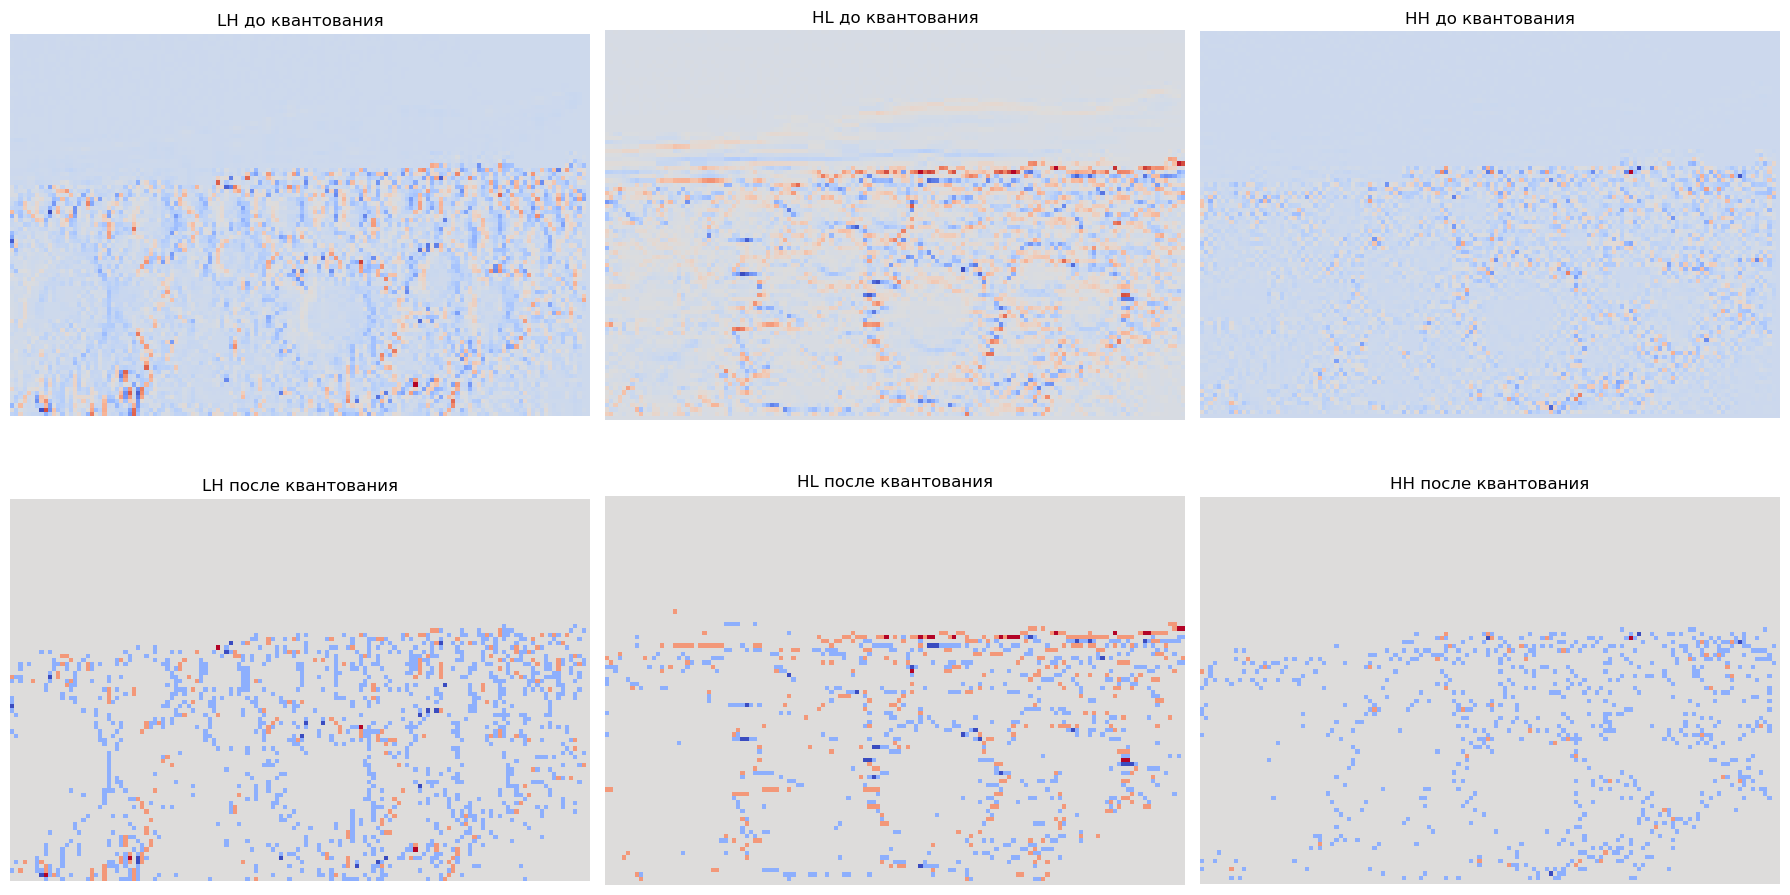

In [14]:
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(LH, cmap='coolwarm'); plt.title('LH до квантования'); plt.axis('off')
plt.subplot(2, 3, 2); plt.imshow(HL, cmap='coolwarm'); plt.title('HL до квантования'); plt.axis('off')
plt.subplot(2, 3, 3); plt.imshow(HH, cmap='coolwarm'); plt.title('HH до квантования'); plt.axis('off')

plt.subplot(2, 3, 4); plt.imshow(LH_q, cmap='coolwarm'); plt.title('LH после квантования'); plt.axis('off')
plt.subplot(2, 3, 5); plt.imshow(HL_q, cmap='coolwarm'); plt.title('HL после квантования'); plt.axis('off')
plt.subplot(2, 3, 6); plt.imshow(HH_q, cmap='coolwarm'); plt.title('HH после квантования'); plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
def run_length_encode(data):
    encoded = []
    for value, count in Counter(data.flatten()).items():
        encoded.append((value, count))
    return encoded

LH_rle = run_length_encode(LH_q)
HL_rle = run_length_encode(HL_q)
HH_rle = run_length_encode(HH_q)

In [7]:
with open('wavelet.txt', 'w') as f:
    np.savetxt(f, LL, fmt='%d')
    f.write('\n')
    for value, count in LH_rle:
        f.write(f"{value} {count}\n")
    f.write('\n')
    for value, count in HL_rle:
        f.write(f"{value} {count}\n")
    f.write('\n')
    for value, count in HH_rle:
        f.write(f"{value} {count}\n")

original_size = img.nbytes
compressed_size = 0
with open('wavelet.txt', 'r') as f:
    compressed_size = len(f.read().encode('utf-8'))

print(f"размер исходного изображения: {original_size}")
print(f"размер сжатого изображения: {compressed_size}")
print(f"степень сжатия: {original_size / compressed_size:.2f}")

размер исходного изображения: 201300
размер сжатого изображения: 44762
степень сжатия: 4.50
